In [1]:
# Installing GEOparse
!pip install GEOparse --quiet
# Core data handling
import pandas as pd
import numpy as np
# Statistics
from scipy import stats
from statsmodels.stats.multitest import multipletests
# Machine learning (for PCA)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# GEO data access
import GEOparse
# Misc utilities
import os
import warnings
warnings.filterwarnings('ignore')  # suppresses noisy GEOparse/pandas version warnings
# Consistent plot styling for the whole notebook
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
# Creating the project folder structure directly in the Colab session
folders = [
    "data/raw",
    "data/processed",
    "figures",
    "results"
]
for f in folders:
    os.makedirs(f, exist_ok=True)
print(" Environment ready.")
print("Folders created:", os.listdir("."))

 Environment ready.
Folders created: ['.config', 'results', 'data', 'figures', 'sample_data']


In [2]:
# downloading the Series Matrix + metadata directly from NCBI GEO's FTP server.
gse = GEOparse.get_GEO(geo="GSE10072", destdir="data/raw/")
# Quick confirmation
print("Dataset title:", gse.metadata.get('title', ['N/A'])[0])
print("Number of samples downloaded:", len(gse.gsms))
print("Platform(s):", list(gse.gpls.keys()))

15-Jul-2026 08:38:08 DEBUG utils - Directory data/raw/ already exists. Skipping.
DEBUG:GEOparse:Directory data/raw/ already exists. Skipping.
15-Jul-2026 08:38:08 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE10nnn/GSE10072/soft/GSE10072_family.soft.gz to data/raw/GSE10072_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE10nnn/GSE10072/soft/GSE10072_family.soft.gz to data/raw/GSE10072_family.soft.gz
100%|██████████| 25.6M/25.6M [00:00<00:00, 65.6MB/s]
15-Jul-2026 08:38:08 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
15-Jul-2026 08:38:08 DEBUG downloader - Moving /tmp/tmp2t3tjsxp to /content/data/raw/GSE10072_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp2t3tjsxp to /content/data/raw/GSE10072_family.soft.gz
15-Jul-2026 08:38:08 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE10nnn/GSE10072/soft/GSE10072_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://

Dataset title: Gene expression signature of cigarette smoking and its role in lung adenocarcinoma development and survival
Number of samples downloaded: 107
Platform(s): ['GPL96']


In [3]:
# Extracting the expression matrix: rows = probe IDs, columns = GSM sample IDs
expression_df = gse.pivot_samples('VALUE')
print("Expression matrix shape (probes x samples):", expression_df.shape)
print()
print("First 5 rows / 5 columns:")
display(expression_df.iloc[:5, :5])
# Extract per-sample metadata (title, tissue source, etc.)
metadata_rows = []
for gsm_name, gsm in gse.gsms.items():
    metadata_rows.append({
        "sample_id": gsm_name,
        "title": gsm.metadata.get("title", [""])[0],
        "source_name": gsm.metadata.get("source_name_ch1", [""])[0],
        "characteristics": " | ".join(gsm.metadata.get("characteristics_ch1", []))
    })
sample_metadata = pd.DataFrame(metadata_rows).set_index("sample_id")
print("\nSample metadata preview:")
display(sample_metadata.head(10))
# Check value range — tells us if data is already log2-transformed or raw linear intensity
print("\nValue range across entire matrix:")
print("Min:", expression_df.values.min())
print("Max:", expression_df.values.max())
print("Mean:", expression_df.values.mean())
# Saving raw extracted versions immediately so we never need to re-download
expression_df.to_csv("data/processed/expression_raw_extracted.csv")
sample_metadata.to_csv("data/processed/sample_metadata_raw.csv")

Expression matrix shape (probes x samples): (22283, 107)

First 5 rows / 5 columns:


name,GSM254625,GSM254626,GSM254627,GSM254628,GSM254629
ID_REF,,,,,
1007_s_at,10.927084,10.416978,10.628538,10.151180,10.988512
1053_at,6.895217,6.924856,7.550245,6.699557,6.826031
117_at,8.110190,7.760228,7.974676,7.712676,7.775592
121_at,9.451286,9.520943,9.807597,9.522087,9.855061
1255_g_at,4.814477,4.718640,4.905163,4.818076,4.823958



Sample metadata preview:


,title,source_name,characteristics
sample_id,,,
GSM254625,Lung Tumor_GT00006,Adenocarcinoma of the Lung,Gender: Male | Age at Diagnosis: 69 | Cigarett...
GSM254626,Normal Lung_GT00006,Normal Lung Tissue,Gender: Male | Age at Diagnosis: 69 | Cigarett...
GSM254627,Lung Tumor_GT00007,Adenocarcinoma of the Lung,Gender: Male | Age at Diagnosis: 68 | Cigarett...
GSM254628,Normal Lung_GT00007,Normal Lung Tissue,Gender: Male | Age at Diagnosis: 68 | Cigarett...
GSM254629,Lung Tumor_GT00022,Adenocarcinoma of the Lung,Gender: Female | Age at Diagnosis: 74 | Cigare...
GSM254630,Lung Tumor_GT00042,Adenocarcinoma of the Lung,Gender: Male | Age at Diagnosis: 75 | Cigarett...
GSM254631,Lung Tumor_GT00059,Adenocarcinoma of the Lung,Gender: Male | Age at Diagnosis: 67 | Cigarett...
GSM254632,Normal Lung_GT00059,Normal Lung Tissue,Gender: Male | Age at Diagnosis: 67 | Cigarett...
GSM254633,Lung Tumor_GT00146,Adenocarcinoma of the Lung,Gender: Male | Age at Diagnosis: 71 | Cigarett...



Value range across entire matrix:
Min: 3.670126391
Max: 15.24822482
Mean: 7.527759324426871


In [4]:
# DATA CLEANING
print("Missing values before cleaning:", expression_df.isnull().sum().sum())
# 1. Drop rows (probes) with ANY missing value
expression_clean = expression_df.dropna(axis=0, how='any')
print("Shape after dropping rows with missing values:", expression_clean.shape)
# 2. Remove Affymetrix control probes — these measure array quality, not genes
control_probes = [p for p in expression_clean.index if p.startswith("AFFX")]
print(f"Found {len(control_probes)} control probes — removing them")
expression_clean = expression_clean.drop(index=control_probes)
# 3. Handle non-positive values before any log transform
n_nonpositive = (expression_clean <= 0).sum().sum()
print(f"Non-positive values found: {n_nonpositive}")
if n_nonpositive > 0:
    # Floor tiny/negative background-corrected intensities to a small positive value
    floor_value = 1.0
    expression_clean = expression_clean.clip(lower=floor_value)
    print(f"Clipped all values below {floor_value} up to {floor_value}")
# 4. Confirm no duplicate probe IDs (would break gene-level analysis later)
n_duplicates = expression_clean.index.duplicated().sum()
print("Duplicate probe IDs:", n_duplicates)
print("\nFinal cleaned shape:", expression_clean.shape)
# Save cleaned matrix
expression_clean.to_csv("data/processed/expression_clean.csv")

Missing values before cleaning: 0
Shape after dropping rows with missing values: (22283, 107)
Found 68 control probes — removing them
Non-positive values found: 0
Duplicate probe IDs: 0

Final cleaned shape: (22215, 107)


In [5]:
# SAMPLE GROUP LABELING
print("Sample metadata text to classify from:\n")
for sid in sample_metadata.index[:5]:
    row = sample_metadata.loc[sid]
    print(sid, "|", row['title'], "|", row['source_name'], "|", row['characteristics'])
def classify_sample(row):
    """
    Classifies a sample as 'Tumor' or 'Normal' by searching title,
    source_name, and characteristics text for keywords.
    Adjust the keyword lists below if your printed output above
    uses different wording.
    """
    text = f"{row['title']} {row['source_name']} {row['characteristics']}".lower()
    normal_keywords = ["normal", "non-tumor", "non tumor", "adjacent", "control"]
    tumor_keywords  = ["tumor", "tumour", "cancer", "adenocarcinoma", "carcinoma", "malignant"]
    is_normal = any(kw in text for kw in normal_keywords)
    is_tumor  = any(kw in text for kw in tumor_keywords)
    if is_normal and not is_tumor:
        return "Normal"
    elif is_tumor and not is_normal:
        return "Tumor"
    else:
        return "Unclear"  # flagged for manual review
sample_metadata["group"] = sample_metadata.apply(classify_sample, axis=1)
print("\nGroup counts:")
print(sample_metadata["group"].value_counts())
# If any samples are "Unclear", inspect them manually and fix by hand:
unclear = sample_metadata[sample_metadata["group"] == "Unclear"]
if len(unclear) > 0:
    print("\n Unclear samples — inspect these manually:")
    display(unclear)
else:
    print("\n All 107 samples classified with no ambiguity.")
# Save the finalized metadata with group labels
sample_metadata.to_csv("data/processed/sample_metadata_labeled.csv")

Sample metadata text to classify from:

GSM254625 | Lung Tumor_GT00006 | Adenocarcinoma of the Lung | Gender: Male | Age at Diagnosis: 69 | Cigarette Smoking Status: Never Smoked | Stage:IIB
GSM254626 | Normal Lung_GT00006 | Normal Lung Tissue | Gender: Male | Age at Diagnosis: 69 | Cigarette Smoking Status: Never Smoked | Stage:IIB
GSM254627 | Lung Tumor_GT00007 | Adenocarcinoma of the Lung | Gender: Male | Age at Diagnosis: 68 | Cigarette Smoking Status: Former Smoker | Stage:IIB
GSM254628 | Normal Lung_GT00007 | Normal Lung Tissue | Gender: Male | Age at Diagnosis: 68 | Cigarette Smoking Status: Former Smoker | Stage:IIB
GSM254629 | Lung Tumor_GT00022 | Adenocarcinoma of the Lung | Gender: Female | Age at Diagnosis: 74 | Cigarette Smoking Status: Never Smoked | Stage:IB

Group counts:
group
Tumor     58
Normal    49
Name: count, dtype: int64

 All 107 samples classified with no ambiguity.


In [6]:
# PREPROCESSING
max_val = expression_clean.values.max()
if max_val > 50:
    print(f"Max value = {max_val:.1f} → data appears linear-scale. Applying log2 transform.")
    expression_log = np.log2(expression_clean)
else:
    print(f"Max value = {max_val:.1f} → data appears already log2-scale. No transform applied.")
    expression_log = expression_clean.copy()
print("Post-transform range: min =", expression_log.values.min(), ", max =", expression_log.values.max())
# --- 6b. Pull GPL96 platform annotation (probe -> gene symbol mapping) --
gpl = gse.gpls['GPL96']
annotation_table = gpl.table
print("\nAnnotation table columns available:")
print(annotation_table.columns.tolist())
# GPL96's standard column is 'Gene Symbol' — if the printed list above shows a
# different name, update GENE_SYMBOL_COL to match exactly.
GENE_SYMBOL_COL = "Gene Symbol"
probe_to_gene = annotation_table.set_index("ID")[GENE_SYMBOL_COL]
print("\nSample of probe -> gene mapping:")
print(probe_to_gene.head())
# --- 6c. Attach gene symbols to the expression matrix --
expression_log = expression_log.copy()
expression_log["gene_symbol"] = expression_log.index.map(probe_to_gene)
# Drop probes with no gene symbol (unannotated / control sequences)
before = expression_log.shape[0]
expression_log = expression_log.dropna(subset=["gene_symbol"])
expression_log = expression_log[expression_log["gene_symbol"].str.strip() != ""]
after = expression_log.shape[0]
print(f"\nDropped {before - after} probes with no gene symbol annotation")
# --- 6d. Collapse multiple probes mapping to the same gene --
# Standard approach: keep the probe with the highest mean expression per gene
# (the most reliably detected probe for that gene across all samples)
sample_cols = [c for c in expression_log.columns if c != "gene_symbol"]
expression_log["mean_expr"] = expression_log[sample_cols].mean(axis=1)
expression_gene_level = (
    expression_log
    .sort_values("mean_expr", ascending=False)
    .drop_duplicates(subset="gene_symbol", keep="first")
    .set_index("gene_symbol")[sample_cols]
)
print("\nFinal gene-level matrix shape (genes x samples):", expression_gene_level.shape)
display(expression_gene_level.iloc[:5, :5])
# Save
expression_gene_level.to_csv("data/processed/expression_gene_level.csv")

Max value = 15.2 → data appears already log2-scale. No transform applied.
Post-transform range: min = 3.670126391 , max = 15.24822482

Annotation table columns available:
['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date', 'Sequence Type', 'Sequence Source', 'Target Description', 'Representative Public ID', 'Gene Title', 'Gene Symbol', 'ENTREZ_GENE_ID', 'RefSeq Transcript ID', 'Gene Ontology Biological Process', 'Gene Ontology Cellular Component', 'Gene Ontology Molecular Function']

Sample of probe -> gene mapping:
ID
1007_s_at    DDR1 /// MIR4640
1053_at                  RFC2
117_at                  HSPA6
121_at                   PAX8
1255_g_at              GUCA1A
Name: Gene Symbol, dtype: object

Dropped 1000 probes with no gene symbol annotation

Final gene-level matrix shape (genes x samples): (13515, 107)


name,GSM254625,GSM254626,GSM254627,GSM254628,GSM254629
gene_symbol,,,,,
EEF1A1,14.100282,14.326392,13.990101,14.317905,14.494477
RPL41,14.035280,14.255656,13.973827,14.262657,14.316178
LOC101928826 /// TPT1,14.100360,14.264790,14.068989,14.272950,14.324852
ACTB,14.230467,14.104713,14.117492,13.979120,14.122368
HLA-B,14.658957,14.286239,14.576771,14.325294,13.897356


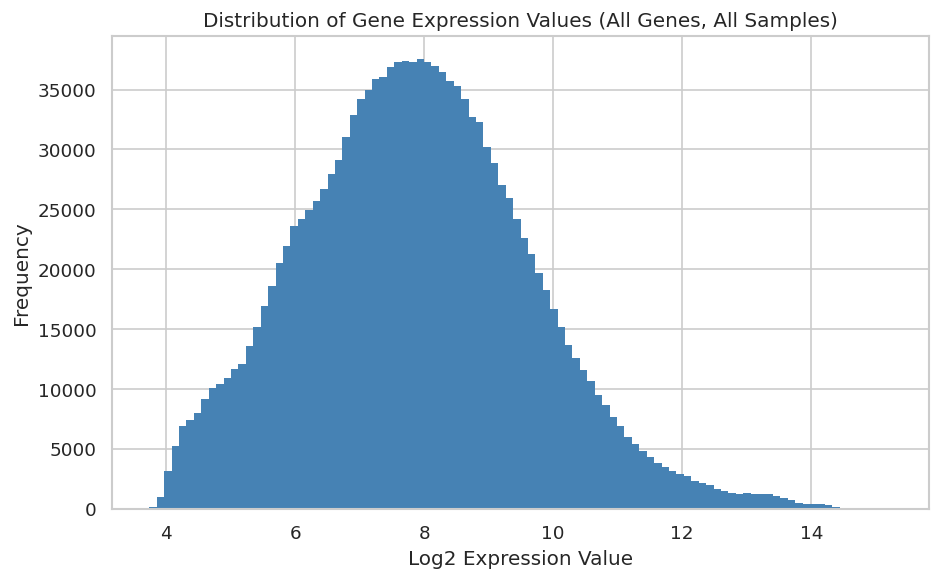

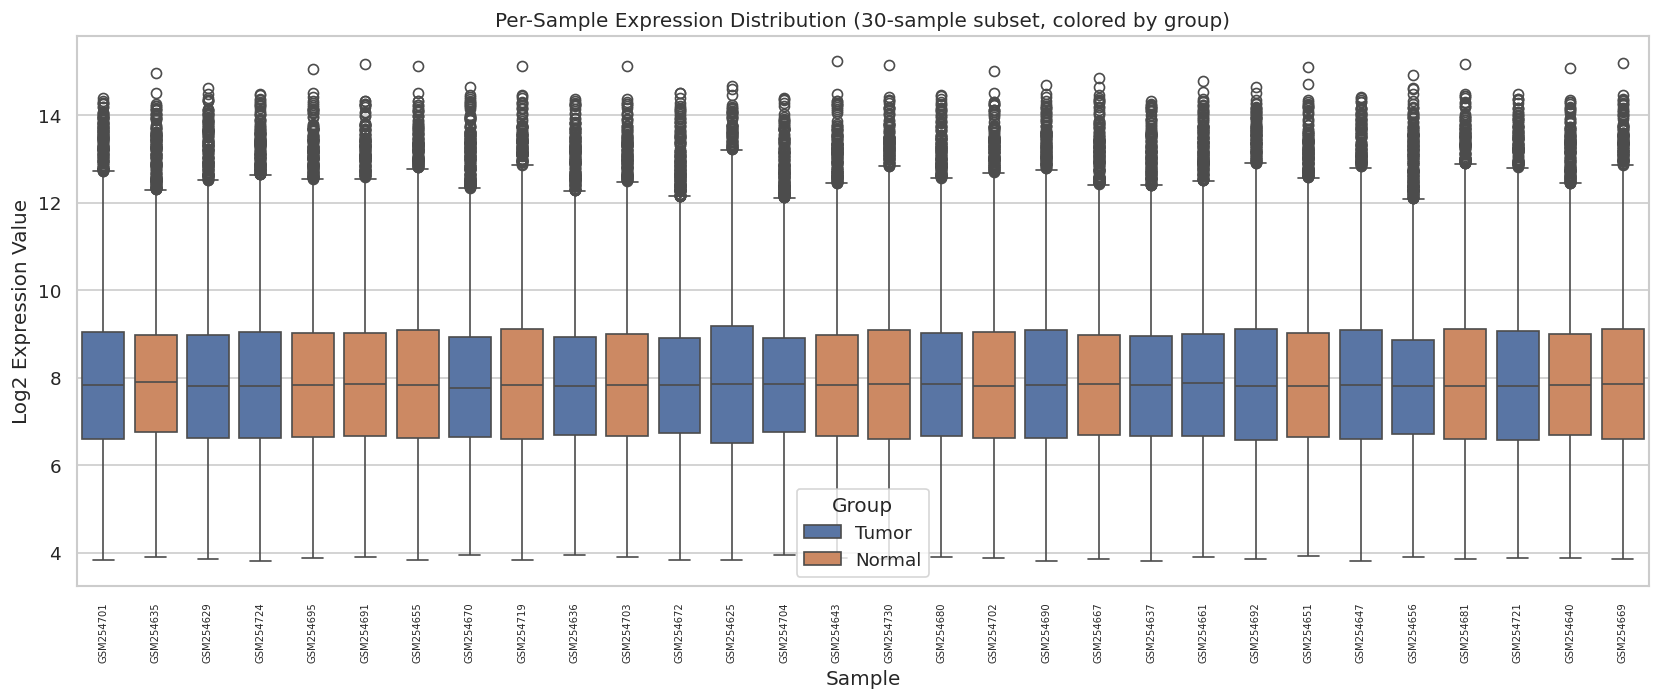

In [7]:
# EXPLORATORY DATA ANALYSIS
# --- a. Histogram: overall distribution of expression values --
plt.figure(figsize=(8, 5))
plt.hist(expression_gene_level.values.flatten(), bins=100, color="steelblue", edgecolor="none")
plt.xlabel("Log2 Expression Value")
plt.ylabel("Frequency")
plt.title("Distribution of Gene Expression Values (All Genes, All Samples)")
plt.tight_layout()
plt.savefig("figures/histogram_expression.png")
plt.show()
# --- b. Boxplot: per-sample distribution, colored by group --
# Using a random subset of 30 samples keeps the plot readable; swap for
# expression_gene_level.columns to plot all 107 if we prefer.
plot_samples = sample_metadata.sample(30, random_state=42).index.tolist()
plot_data = expression_gene_level[plot_samples].melt(var_name="sample_id", value_name="expression")
plot_data = plot_data.merge(sample_metadata[["group"]], left_on="sample_id", right_index=True)
plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_data, x="sample_id", y="expression", hue="group", dodge=False)
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("Sample")
plt.ylabel("Log2 Expression Value")
plt.title("Per-Sample Expression Distribution (30-sample subset, colored by group)")
plt.legend(title="Group")
plt.tight_layout()
plt.savefig("figures/boxplot_samples.png")
plt.show()

PC1 explains 32.9% of variance
PC2 explains 7.0% of variance


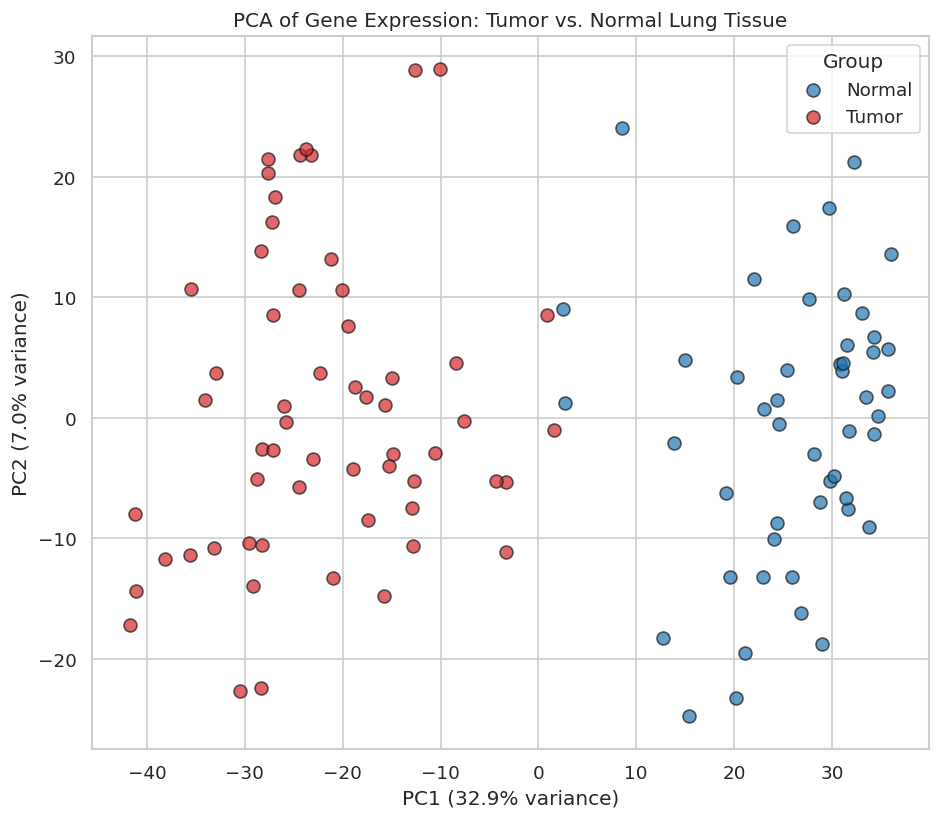

In [8]:
# PCA ANALYSIS
# Samples must be rows and genes must be columns for PCA — transpose the matrix
expr_for_pca = expression_gene_level.T  # now: samples x genes
# Select top 2000 most variable genes — reduces noise, speeds up computation,
# and is standard practice before PCA on expression data.
gene_variance = expression_gene_level.var(axis=1)
top_genes = gene_variance.sort_values(ascending=False).head(2000).index
expr_top = expr_for_pca[top_genes]
# Standardize (mean 0, variance 1 per gene) — required before PCA
scaler = StandardScaler()
expr_scaled = scaler.fit_transform(expr_top)
# Run PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(expr_scaled)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"], index=expr_top.index)
pca_df = pca_df.merge(sample_metadata[["group"]], left_index=True, right_index=True)
explained_var = pca.explained_variance_ratio_ * 100
print(f"PC1 explains {explained_var[0]:.1f}% of variance")
print(f"PC2 explains {explained_var[1]:.1f}% of variance")
# Plot
plt.figure(figsize=(8, 7))
colors = {"Tumor": "#d62728", "Normal": "#1f77b4"}
for group_name, group_df in pca_df.groupby("group"):
    plt.scatter(group_df["PC1"], group_df["PC2"], label=group_name,
                c=colors.get(group_name, "gray"), alpha=0.7, edgecolor="k", s=60)
plt.xlabel(f"PC1 ({explained_var[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]:.1f}% variance)")
plt.title("PCA of Gene Expression: Tumor vs. Normal Lung Tissue")
plt.legend(title="Group")
plt.tight_layout()
plt.savefig("figures/pca_plot.png")
plt.show()

In [13]:
# DIFFERENTIAL GENE EXPRESSION ANALYSIS

# Get sample IDs for each group
tumor_samples = sample_metadata[sample_metadata["group"] == "Tumor"].index.tolist()
normal_samples = sample_metadata[sample_metadata["group"] == "Normal"].index.tolist()

print(f"Tumor samples: {len(tumor_samples)} | Normal samples: {len(normal_samples)}")

results = []

# Loop through each gene
for gene in expression_gene_level.index:

    tumor_vals = expression_gene_level.loc[gene, tumor_samples].values
    normal_vals = expression_gene_level.loc[gene, normal_samples].values

    # Welch's two-sample t-test
    t_stat, p_val = stats.ttest_ind(
        tumor_vals,
        normal_vals,
        equal_var=False
    )

    # Since the data is already log2-transformed,
    # the difference of means equals the log2 fold change.
    log2fc = tumor_vals.mean() - normal_vals.mean()

    results.append({
        "gene": gene,
        "log2FC": log2fc,
        "t_statistic": t_stat,
        "p_value": p_val,
        "mean_tumor": tumor_vals.mean(),
        "mean_normal": normal_vals.mean()
    })

# Convert to DataFrame
deg_results = pd.DataFrame(results)

# Benjamini-Hochberg FDR correction
reject, adj_pvals, _, _ = multipletests(
    deg_results["p_value"],
    method="fdr_bh"
)

deg_results["adj_p_value"] = adj_pvals

# Significance thresholds
LOG2FC_THRESHOLD = 1.0      # |log2FC| > 1 (2-fold change)
PADJ_THRESHOLD = 0.05

deg_results["significant"] = (
    (deg_results["adj_p_value"] < PADJ_THRESHOLD) &
    (deg_results["log2FC"].abs() > LOG2FC_THRESHOLD)
)

# Assign direction
deg_results["direction"] = np.select(
    [
        deg_results["significant"] & (deg_results["log2FC"] > 0),
        deg_results["significant"] & (deg_results["log2FC"] < 0)
    ],
    [
        "Upregulated in Tumor",
        "Downregulated in Tumor"
    ],
    default="Not Significant"
)

# Sort by adjusted p-value
deg_results = deg_results.sort_values("adj_p_value")

# Print summary
print("\nTotal genes tested:", len(deg_results))
print("Significant genes:", deg_results["significant"].sum())
print(deg_results["direction"].value_counts())

# Display top results
display(deg_results.head(10))

# Save results
deg_results.to_csv("results/DEG_full_results.csv", index=False)

Tumor samples: 58 | Normal samples: 49

Total genes tested: 13515
Significant genes: 600
direction
Not Significant           12915
Downregulated in Tumor      390
Upregulated in Tumor        210
Name: count, dtype: int64


,gene,log2FC,t_statistic,p_value,mean_tumor,mean_normal,adj_p_value,significant,direction
3359,FAM107A,-3.371799,-23.819874,6.641899e-44,7.451084,10.822883,8.976527e-40,True,Downregulated in Tumor
6298,CDH5,-2.619573,-21.743297,1.317136e-40,6.804586,9.424160,8.900545e-37,True,Downregulated in Tumor
712,PECAM1,-1.813914,-20.933864,3.357325e-39,9.836642,11.650556,1.512475e-35,True,Downregulated in Tumor
5738,STARD13,-1.219820,-20.838832,5.221337e-39,7.630347,8.850167,1.764159e-35,True,Downregulated in Tumor
2250,AGER,-4.417470,-20.989043,4.769095e-38,7.459343,11.876812,1.289086e-34,True,Downregulated in Tumor
763,VWF,-2.258474,-20.904174,1.464679e-37,9.567466,11.825939,3.011365e-34,True,Downregulated in Tumor
4540,HIGD1B,-1.363973,-20.963402,1.714932e-37,7.949560,9.313533,3.011365e-34,True,Downregulated in Tumor
1871,SPP1,4.364415,20.546467,1.782532e-37,11.697897,7.333482,3.011365e-34,True,Upregulated in Tumor
3644,FABP4,-3.838541,-20.004832,2.254575e-37,7.136529,10.975070,3.385620e-34,True,Downregulated in Tumor
3624,CLEC3B /// EXOSC7,-3.411853,-20.773669,3.251662e-37,7.338750,10.750604,3.729818e-34,True,Downregulated in Tumor


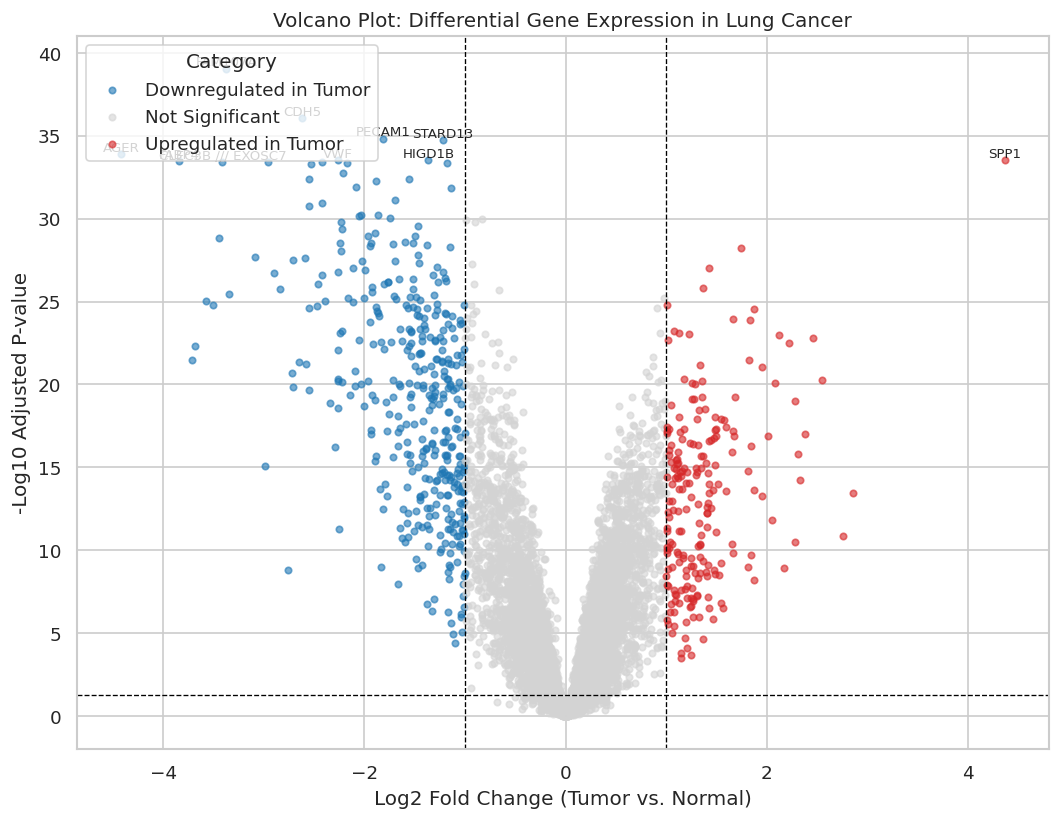

In [14]:
# VOLCANO PLOT
deg_results["neg_log10_padj"] = -np.log10(deg_results["adj_p_value"].replace(0, 1e-300))
plt.figure(figsize=(9, 7))
color_map = {
    "Upregulated in Tumor": "#d62728",
    "Downregulated in Tumor": "#1f77b4",
    "Not Significant": "lightgray"
}
for direction, subset in deg_results.groupby("direction"):
    plt.scatter(subset["log2FC"], subset["neg_log10_padj"],
                c=color_map[direction], label=direction, alpha=0.6, s=15)
# Threshold reference lines
plt.axhline(-np.log10(PADJ_THRESHOLD), color="black", linestyle="--", linewidth=0.8)
plt.axvline(LOG2FC_THRESHOLD, color="black", linestyle="--", linewidth=0.8)
plt.axvline(-LOG2FC_THRESHOLD, color="black", linestyle="--", linewidth=0.8)
# Label the top 10 most significant genes
top10 = deg_results[deg_results["significant"]].head(10)
for _, row in top10.iterrows():
    plt.text(row["log2FC"], row["neg_log10_padj"], row["gene"],
              fontsize=8, ha="center", va="bottom")
plt.xlabel("Log2 Fold Change (Tumor vs. Normal)")
plt.ylabel("-Log10 Adjusted P-value")
plt.title("Volcano Plot: Differential Gene Expression in Lung Cancer")
plt.legend(title="Category", loc="upper left")
plt.tight_layout()
plt.savefig("figures/volcano_plot.png")
plt.show()

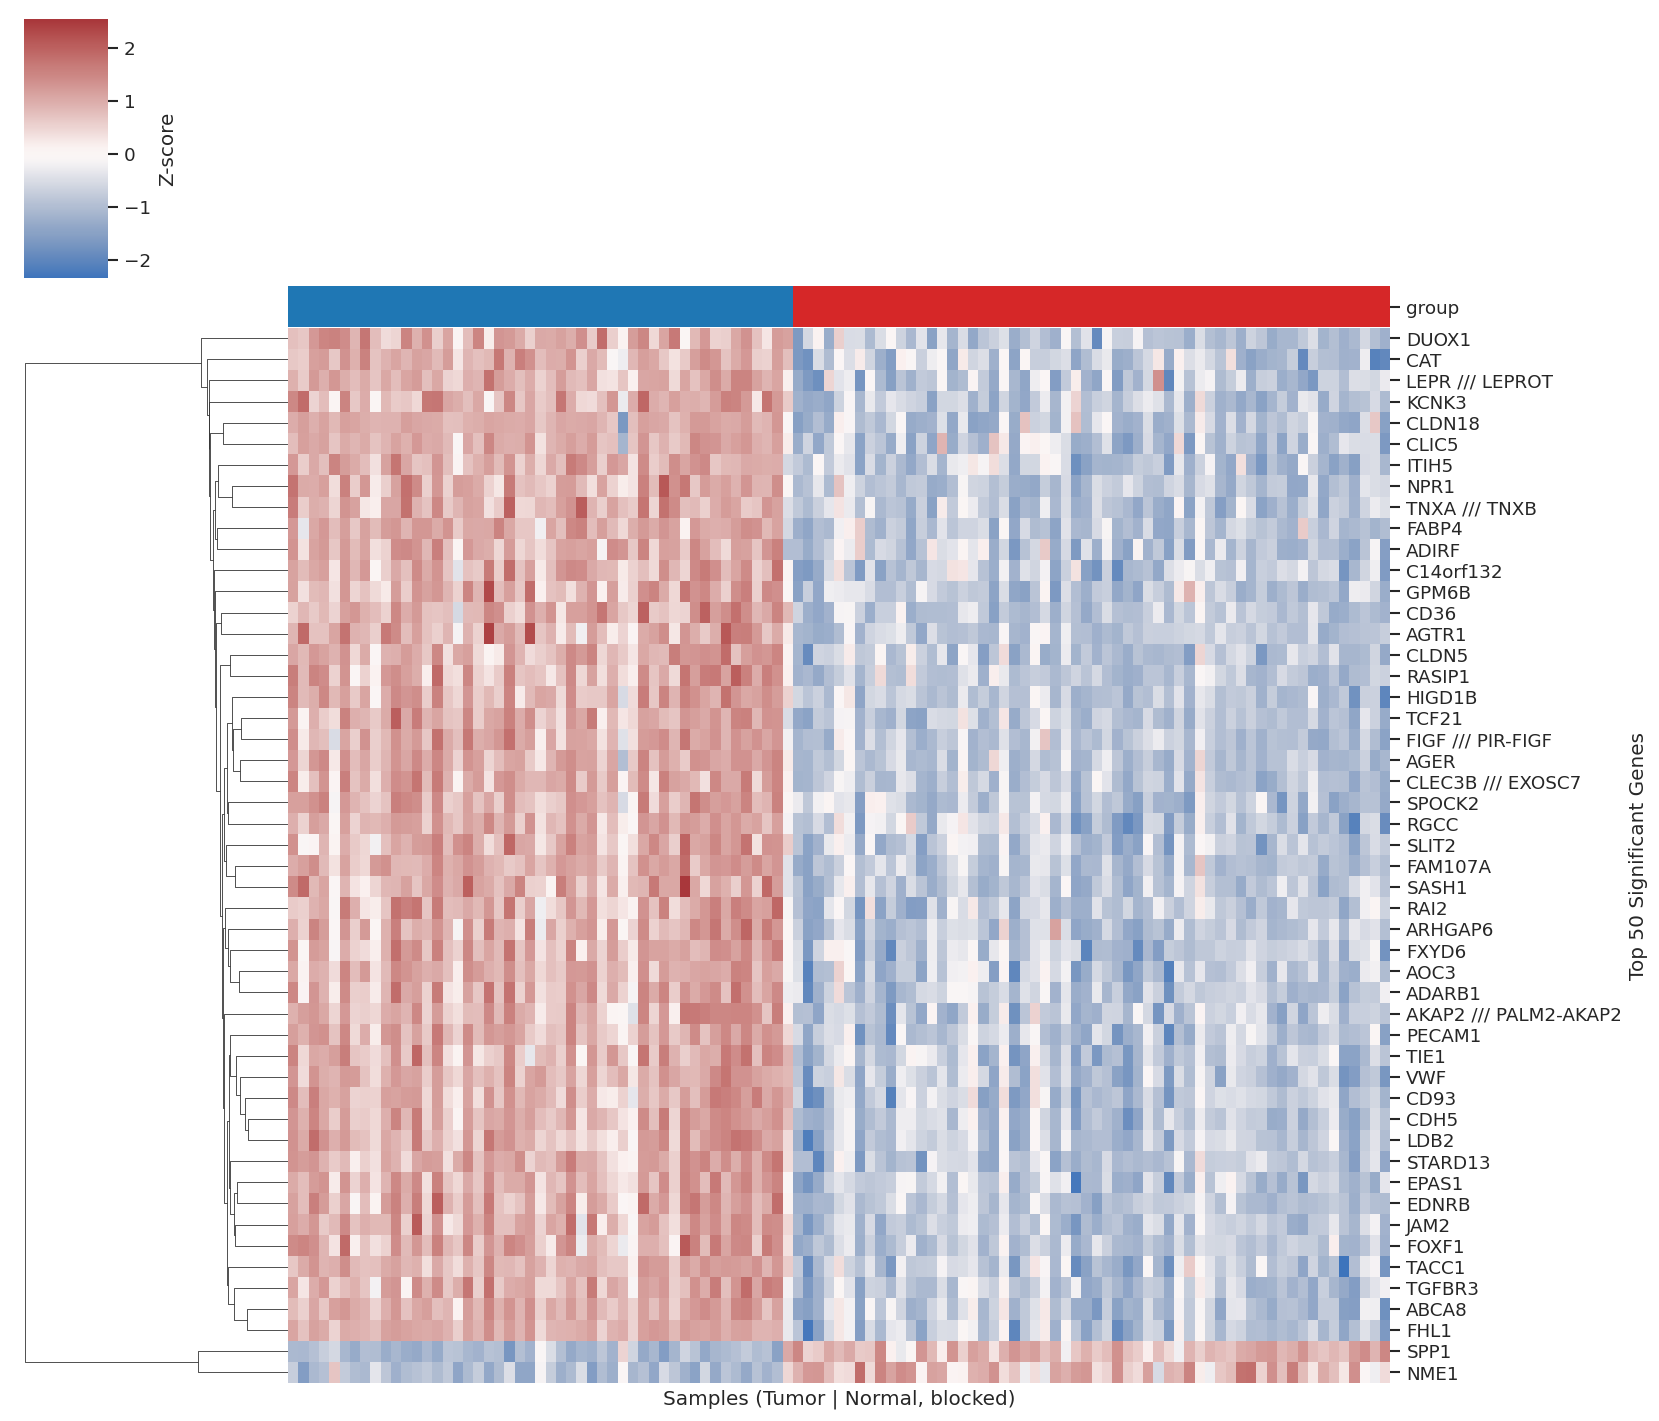

In [15]:
# HEATMAP OF TOP GENES
top50_genes = deg_results[deg_results["significant"]].head(50)["gene"].tolist()
heatmap_data = expression_gene_level.loc[top50_genes]
# Z-score normalize each gene (row) across all samples — puts every gene on the
# same scale so the heatmap color reflects relative pattern, not absolute expression
heatmap_zscore = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0).div(heatmap_data.std(axis=1), axis=0)
# Order samples by group so the heatmap visually splits into two clear blocks
ordered_samples = sample_metadata.sort_values("group").index.tolist()
heatmap_zscore = heatmap_zscore[ordered_samples]
# Column color bar: red = Tumor, blue = Normal
group_colors = sample_metadata.loc[ordered_samples, "group"].map({"Tumor": "#d62728", "Normal": "#1f77b4"})
g = sns.clustermap(
    heatmap_zscore,
    col_cluster=False,          # keeping samples in Tumor/Normal block order, don't re-cluster
    row_cluster=True,           # do cluster genes by similarity
    col_colors=group_colors,
    cmap="vlag",
    center=0,
    figsize=(14, 12),
    xticklabels=False,          # 107 sample labels would be unreadable
    yticklabels=True,
    cbar_kws={"label": "Z-score"}
)
g.ax_heatmap.set_xlabel("Samples (Tumor | Normal, blocked)")
g.ax_heatmap.set_ylabel("Top 50 Significant Genes")
plt.savefig("figures/heatmap_top_genes.png", bbox_inches="tight")
plt.show()

In [17]:
# TOP GENES & BIOLOGICAL INTERPRETATION
# Top significantly upregulated genes
top_upregulated = (
    deg_results[deg_results["direction"] == "Upregulated in Tumor"]
    .sort_values("adj_p_value")
    .head(15)
)

# Top significantly downregulated genes
top_downregulated = (
    deg_results[deg_results["direction"] == "Downregulated in Tumor"]
    .sort_values("adj_p_value")
    .head(15)
)

print("TOP 15 UPREGULATED IN TUMOR:")
display(top_upregulated[["gene", "log2FC", "adj_p_value"]])

print("\nTOP 15 DOWNREGULATED IN TUMOR:")
display(top_downregulated[["gene", "log2FC", "adj_p_value"]])

# Literature context for commonly observed lung cancer genes
known_gene_context = {
    "MKI67": "Encodes Ki-67, a standard clinical marker of cell proliferation; frequently elevated in tumors.",
    "TOP2A": "DNA topoisomerase involved in cell division; commonly upregulated in proliferating tumor tissue and is a chemotherapy drug target.",
    "TPX2": "Mitotic spindle assembly factor; often upregulated alongside other proliferation markers in NSCLC.",
    "SPP1": "Encodes osteopontin, associated with tumor invasion and metastasis in several solid cancers.",
    "COL1A1": "Collagen gene; upregulation reflects tumor stroma remodeling and extracellular matrix changes.",
    "COL3A1": "Collagen gene; often co-upregulated with COL1A1 in tumor-associated stromal remodeling.",
    "MMP1": "Matrix metalloproteinase involved in extracellular matrix breakdown; linked to tumor invasion.",
    "MMP9": "Matrix metalloproteinase implicated in tumor invasion and metastasis.",
    "SFTPC": "Surfactant protein C, a marker of healthy alveolar lung tissue; typically downregulated in tumors.",
    "SFTPA1": "Surfactant protein A1, another healthy lung marker; commonly downregulated in tumor tissue.",
    "VEGFA": "Promotes angiogenesis (new blood vessel formation), often upregulated to support tumor growth."
}

print("\nKnown genes identified in your results:")

for gene_list, label in [
    (top_upregulated["gene"], "Upregulated"),
    (top_downregulated["gene"], "Downregulated")
]:
    for gene in gene_list:
        if gene in known_gene_context:
            print(f"[{label}] {gene}: {known_gene_context[gene]}")

# Save significant genes
significant_genes = (
    deg_results[deg_results["significant"]]
    .sort_values("adj_p_value")
)

significant_genes.to_csv(
    "results/DEG_significant_genes.csv",
    index=False
)

print(
    f"\nSaved {len(significant_genes)} significant genes to "
    "results/DEG_significant_genes.csv"
)

TOP 15 UPREGULATED IN TUMOR:


,gene,log2FC,adj_p_value
1871,SPP1,4.364415,3.011365e-34
1861,NME1,1.747713,5.593296e-29
779,KDELR2,1.422270,9.583329e-28
304,MIF,1.366434,1.492686e-26
6309,RCC1,1.010441,1.614778e-25
7982,PPAP2C,1.872453,2.940155e-25
2707,PAICS,1.669104,1.177092e-24
5711,GOLM1,1.831414,1.358715e-24
240,ENO1,1.075911,6.053739e-24
1371,BZW2,1.127627,7.969342e-24



TOP 15 DOWNREGULATED IN TUMOR:


,gene,log2FC,adj_p_value
3359,FAM107A,-3.371799,8.976527e-40
6298,CDH5,-2.619573,8.900545e-37
712,PECAM1,-1.813914,1.512475e-35
5738,STARD13,-1.219820,1.764159e-35
2250,AGER,-4.417470,1.289086e-34
763,VWF,-2.258474,3.011365e-34
4540,HIGD1B,-1.363973,3.011365e-34
3644,FABP4,-3.838541,3.385620e-34
5514,CD36,-2.416984,3.729818e-34
6813,ABCA8,-2.959910,3.729818e-34



Known genes identified in your results:
[Upregulated] SPP1: Encodes osteopontin, associated with tumor invasion and metastasis in several solid cancers.
[Upregulated] TOP2A: DNA topoisomerase involved in cell division; commonly upregulated in proliferating tumor tissue and is a chemotherapy drug target.

Saved 600 significant genes to results/DEG_significant_genes.csv


In [18]:
# EXPORTING PROJECT
import os
import shutil

print("Checking project files...\n")

expected_files = [
    "data/processed/expression_gene_level.csv",
    "data/processed/sample_metadata_labeled.csv",
    "figures/histogram_expression.png",
    "figures/boxplot_samples.png",
    "figures/pca_plot.png",
    "figures/volcano_plot.png",
    "figures/heatmap_top_genes.png",
    "results/DEG_full_results.csv",
    "results/DEG_significant_genes.csv",
]

missing = []

for f in expected_files:
    if os.path.exists(f):
        print(f"✅ {f}")
    else:
        print(f"❌ Missing: {f}")
        missing.append(f)

if len(missing) == 0:
    print("\nAll expected files found.")
else:
    print(f"\nWarning: {len(missing)} file(s) missing.")

# Create a project folder
project_folder = "gene_expression_project"

if os.path.exists(project_folder):
    shutil.rmtree(project_folder)

os.makedirs(project_folder)

# Copy folders
shutil.copytree("data", os.path.join(project_folder, "data"))
shutil.copytree("figures", os.path.join(project_folder, "figures"))
shutil.copytree("results", os.path.join(project_folder, "results"))

# Zip ONLY the project folder
shutil.make_archive(
    "gene_expression_project",
    "zip",
    project_folder
)

print("\nZIP file created successfully!")
print("gene_expression_project.zip")

Checking project files...

✅ data/processed/expression_gene_level.csv
✅ data/processed/sample_metadata_labeled.csv
✅ figures/histogram_expression.png
✅ figures/boxplot_samples.png
✅ figures/pca_plot.png
✅ figures/volcano_plot.png
✅ figures/heatmap_top_genes.png
✅ results/DEG_full_results.csv
✅ results/DEG_significant_genes.csv

All expected files found.

ZIP file created successfully!
gene_expression_project.zip


In [19]:
from google.colab import files
files.download("gene_expression_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>